<a href="https://colab.research.google.com/github/samboy2002/ISCG7424-MAD-Group-Assignment/blob/master/Ai_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('wine.csv')
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   object 
dtypes: float64(11), object(1)
memory usage: 150.0+ KB
None
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70       

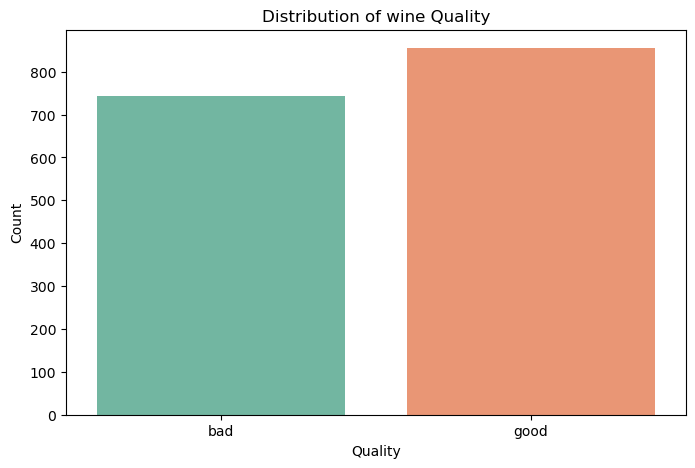

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df, palette='Set2')
plt.title('Distribution of wine Quality')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

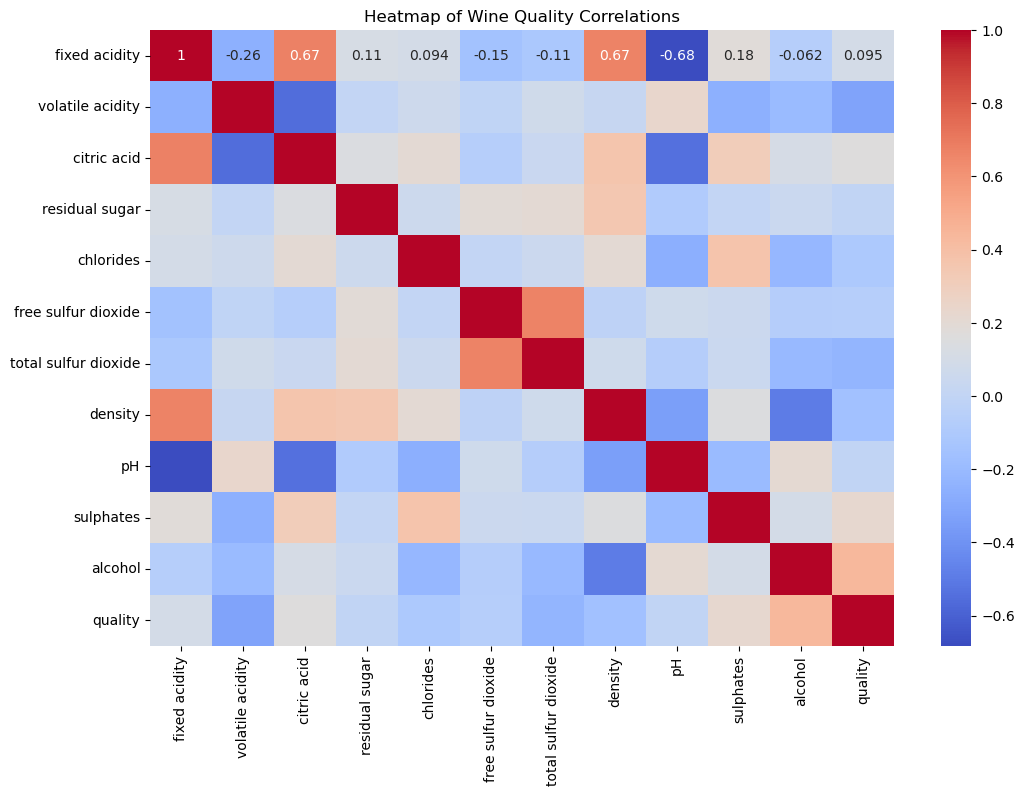

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

wine_data = pd.read_csv('wine.csv')

label_encoder = LabelEncoder()
wine_data['quality'] = label_encoder.fit_transform(wine_data['quality'])#transformation data transformation

plt.figure(figsize=(12, 8))

sns.heatmap(wine_data.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap of Wine Quality Correlations')
plt.show()



C:\Users\pata015\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.5942 - loss: 0.7472 - val_accuracy: 0.7518 - val_loss: 0.5805
Epoch 2/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7163 - loss: 0.5559 - val_accuracy: 0.7701 - val_loss: 0.5455
Epoch 3/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7435 - loss: 0.5234 - val_accuracy: 0.7847 - val_loss: 0.5100
Epoch 4/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7352 - loss: 0.5291 - val_accuracy: 0.7810 - val_loss: 0.4850
Epoch 5/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7374 - loss: 0.5067 - val_accuracy: 0.7920 - val_loss: 0.4653
Epoch 6/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7651 - loss: 0.4832 - val_accuracy: 0.7956 - val_loss: 0.4729
Epoch 7/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7495 - loss: 0.4931 - val_accuracy: 0.7847 - val_loss: 0.4600
Epoch 8/35
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7581 - loss: 0.4800 - val_accuracy: 0.7883 - val_loss

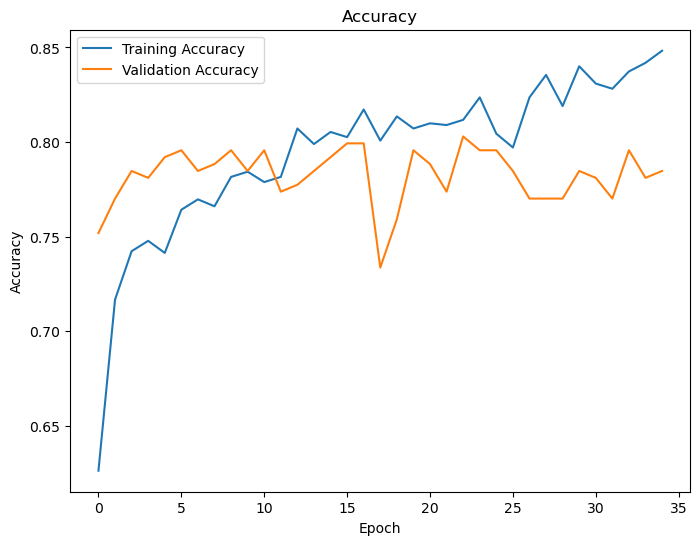

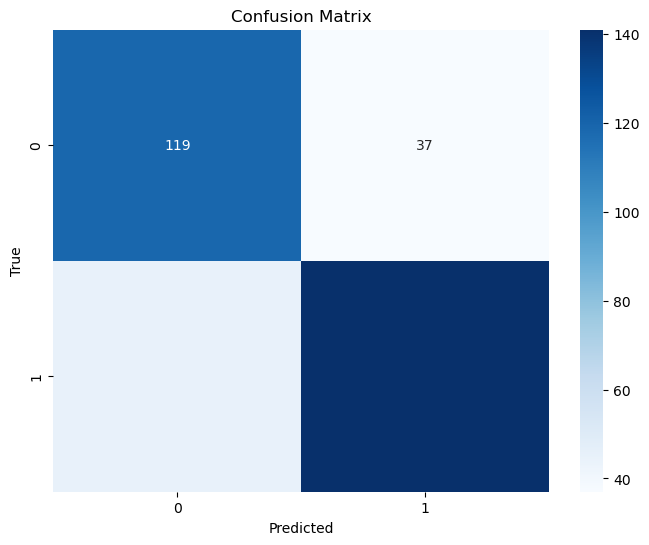

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import cohen_kappa_score
from imblearn.over_sampling import SMOTE

# Load the dataset
wine_data = pd.read_csv('wine.csv')

# Encode the quality labels (good/bad) into binary values
label_encoder = LabelEncoder()
wine_data['quality'] = label_encoder.fit_transform(wine_data['quality'])#transformation data transformation

# Separate features and target variable
X = wine_data.drop('quality', axis=1)
y = wine_data['quality']

# Apply SMOTE
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #converting the values to 0-1 using normalization techniques

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Build the ANN model
#to increase the accuracy we can include another model layer
#--------------------------------------------------------------------------------------------------------------
#dense means how many neurons should be activated such as "relu" an algorithm to select which neuron to use. if all neurons study all ip data it will give the same result
# can use dropout function "or" batch normilization.
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))#64 means the nodes each node has many functions (got a picture in phone) #"shape mean how many features"
model.add(BatchNormalization())
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1, activation='sigmoid'))  # Use 'softmax' if you have multiple classes

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) #loss function calculates the error # metrics=['accuracy'] cross-validation
#can you some other optimizer to increase the accuracy
# Train the model
history = model.fit(X_train, y_train, epochs=35, batch_size=16, validation_split=0.2)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy:.2f}%')
 #the data set it not balanced so it affect the model and (the kappa score is reasonable is because the accuracy is lower this can be improved my sufficient number of data and we need to optimize the model)
# You can use something like the above to add a kappa score
# Make predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")  # Convert probabilities to binary
kappa = cohen_kappa_score(y_test, y_pred)
print(f'kappa score: {kappa:.2f}')
# Print classification report and confusion matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

plt.figure(figsize=(8, 6))
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
! pip3 install matplotlib

In [ ]:
wine_data = pd.read_csv('wine.csv')

quality_counts = wine_data['quality'].value_counts()

print("Counts of quality categories:")
print(quality_counts)

Counts of quality categories:
quality
good    855
bad     744
Name: count, dtype: int64
